In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [21]:
df = pd.read_csv('Dataset- Superstore (2015-2018).csv')
sales_data = df[['Order Date', 'Sales']]

### Extracting Monthly Sales

In [26]:
data = pd.DataFrame()
data['Date'] = pd.to_datetime(sales_data['Order Date'],dayfirst=False)
data['Sales'] = sales_data['Sales']
data = data.set_index('Date')
data.sort_index(inplace=True)
monthly_sales = data.resample('M').sum()
monthly_sales.head()

,Sales
Date,
2014-01-31,14236.895
2014-02-28,4519.892
2014-03-31,55691.009
2014-04-30,28295.345
2014-05-31,23648.287


### Plotting the Monthly Sales

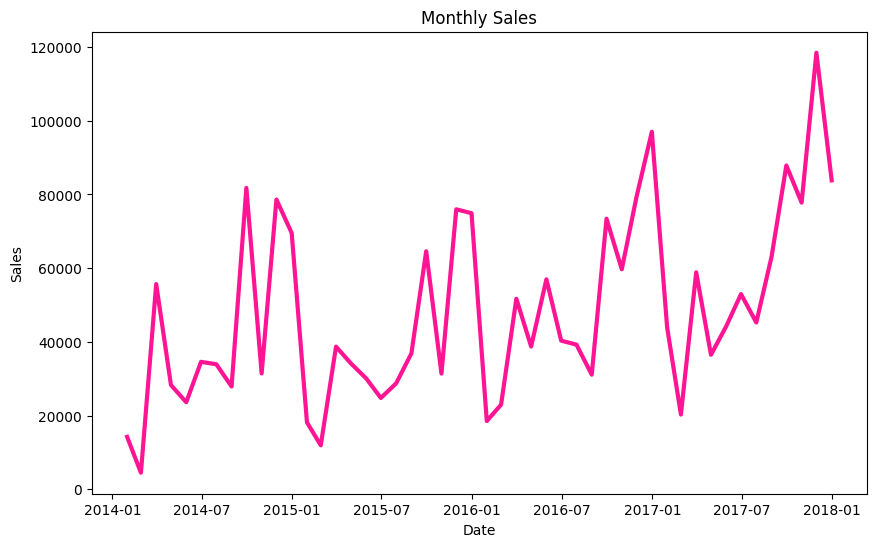

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(monthly_sales['Sales'], linewidth=3, c='deeppink')
plt.title("Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

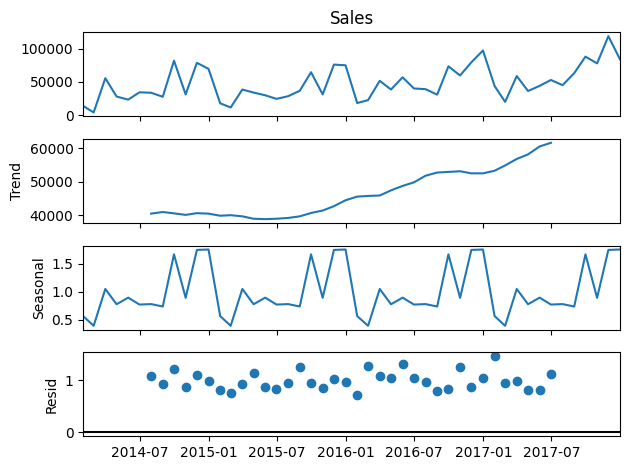

In [51]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(monthly_sales['Sales'], model='multiplicative')
result.plot()
plt.show()

### Stationarity Check

In [31]:
result = adfuller(monthly_sales)
result

(-4.493767844002665,
 0.00020180198458237758,
 0,
 47,
 {'1%': -3.5778480370438146,
  '5%': -2.925338105429433,
  '10%': -2.6007735310095064},
 848.774903223632)

If ADF statistic < critical value → reject H₀

Here, -4.4938 < -3.5778 (1% level) ✅

This means we reject the null hypothesis at even the 1% significance level.

p-value = 0.0002 (very small)

Since p < 0.01, it again indicates strong evidence to reject H₀.

No unit root → mean and variance are stable over time.

You don’t need differencing for ARIMA modeling (d=0).

In [34]:
def check_stationarity(timeseries):
    p_value = result[1]
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {p_value}')
    print('Stationary' if p_value < 0.05 else 'Non-Stationary')


check_stationarity(monthly_sales['Sales'])

ADF Statistic: -4.493767844002665
p-value: 0.00020180198458237758
Stationary


### Identifying Model Parameters

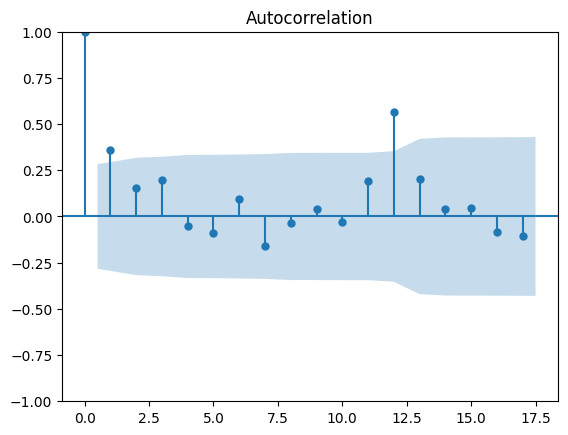

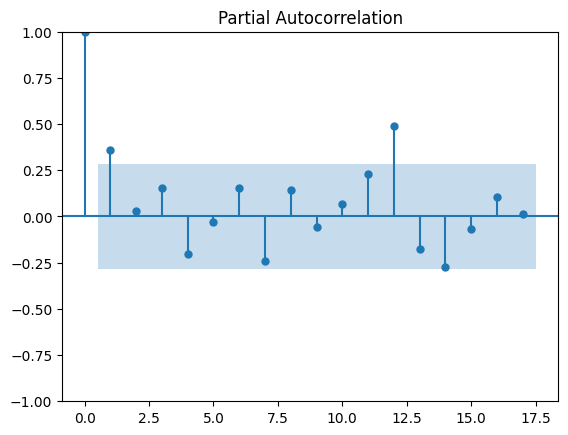

In [35]:
plot_acf(monthly_sales)
plot_pacf(monthly_sales)
plt.show()

### Fitting the SARIMA Model

In [36]:
p, d, q = 1, 1, 1
P, D, Q, s = 1, 1, 1, 12

model = SARIMAX(monthly_sales, order=(p, d, q), seasonal_order=(P, D, Q, s))
results = model.fit()

C:\Users\aksha\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


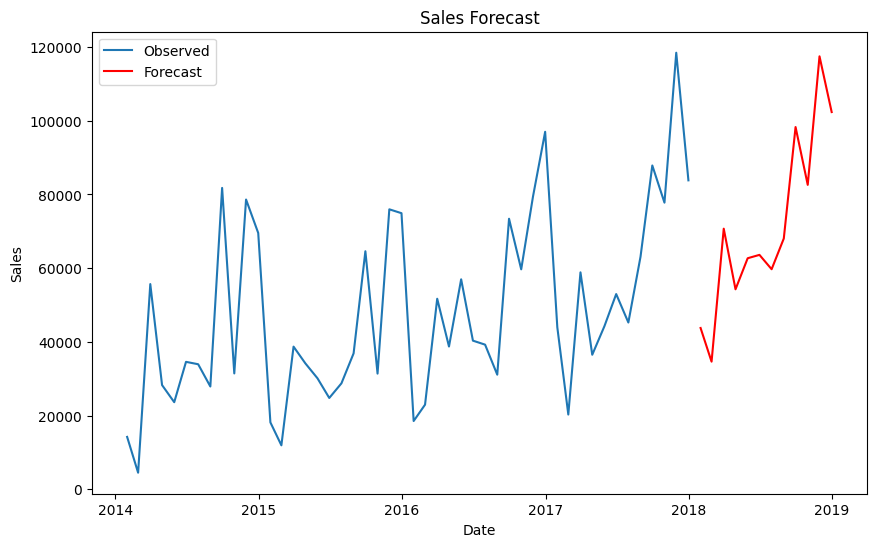

In [37]:
forecast_periods = 12
forecast = results.forecast(steps=forecast_periods)

plt.figure(figsize=(10, 6))
plt.plot(monthly_sales, label='Observed')
plt.plot(forecast, label='Forecast', color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

Evaluation

In [40]:
forecast_mean = [monthly_sales.mean()] * forecast_periods

In [41]:
observed = monthly_sales[-forecast_periods:]
mae = mean_absolute_error(observed, forecast_mean)
mse = mean_squared_error(observed, forecast_mean)
print(f'MAE: {mae}')
print(f'MSE: {mse}')

MAE: 21404.95110729167
MSE: 839647706.4953743
